In [1]:
import eavils_waterfalls as wtrf
import eavils_processing as proc
import eavils_utils
import eavils_prep

import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import sys
import yaml
from copy import deepcopy
import pandas as pd
from astropy.time import Time

## This tutorial walks through how to generate parameters for the EAVILS pol-subtracted metric, and introduces methods for identifying RFI using this metric.

# 0) Initial parameters

#### We can use the initial_freq_flags paramater for pre-emptively flagging systematics like coarse-band lines for the old MWA correlator, or things like known FM or satellite contaminated channels that we'd like to ignore entirely from the outset.

In [2]:
initial_freq_flags = eavils_utils.coarse_band_flagging() 

#### Like in SSINS, shape_dict is used to condition which channels we expect RFI to be combined to. In this case, we also add in an additional "subTV" pseudo-channel added as a control "clean channel". 

#### This subTV channel is quite simply the frequencies below which the digital TV channels live

#### We only want TV channels, so we remove the 'center_packet_loss' frequency type. We also set the parameters we'd like SSINS to run with.

In [3]:
shape_dict = eavils_utils.get_shape_dict('MWA_EoR_Highband_shape_dict.yml',add_MWA_subTV=True)
del shape_dict['center_packet_loss']
print(shape_dict)

ssins_sig_thresh = {shape: 5 for shape in shape_dict}
ssins_sig_thresh["narrow"] = 5
ssins_sig_thresh["streak"] = 10
del ssins_sig_thresh['subTV']

{'TV6': [174000000.0, 181000000.0], 'TV7': [181000000.0, 188000000.0], 'TV8': [188000000.0, 195000000.0], 'TV9': [195000000.0, 202000000.0], 'subTV': [167075000.0, 174000000.0]}


#### Finally, we sort the frequency ranges in our shape_dict according to their minimum frequency. This gets used to organize loops later on in this tutorial. We also establish a pol_dict, which connects the labels of polarizations in our dataset with their ordering in pyuvdata arrays.

#### Then, we set the frequency channel width in Hz, which is used to correctly save and search for files we use and generate.

In [4]:
sorted_freq_ranges,sorted_freq_mins = proc.freq_range_sort(shape_dict)
pol_dict = {'XX':0,'YY':1,'XY':2,'YX':3}
freq_channel_width = 80000 #Channel width in Hz
search_suffix = eavils_prep.freq_channel_width_str(freq_channel_width)+'_cross'

# 1) Initial Processing

#### This section shows how to process raw files (e.g. uvfits files) into data usable for EAVILS. It includes example calls but doesn't actually process data due to raw files being prohibitively large to include on github.

#### The initial processing step reduces the data volume massively by averaging along baselines.

#### Again, this step will not actually process data without downloading the raw (e.g. uvfits) files that we'd like to process. As it stands it should just return a message that the file already exists, e.g. "OUTPUT CHECKING; found \<file_name\>, bypassing spectra outputs", since we have included the output files from this processing for four observations, listed in example_obs_id_list below.


In [5]:

example_obs_id_list = ['1160938096','1160938216','1160938344','1160938464']

raw_data_folder = '<path/to/raw/data>'
example_output_path = 'testing_tutorial'

for obs_id in example_obs_id_list:
    eavils_prep.prep(
        obs_id = obs_id,
        shape_dict = shape_dict,
        input_data_folder=raw_data_folder,
        output_path=example_output_path,
        extension='uvfits',
        freq_channel_width=freq_channel_width,
        initial_flags=initial_freq_flags,
        pol_dict=pol_dict
    )

OUTPUT CHECKING; found testing_tutorial/h5_files/1160938096_80khz_cross_EAVILS_data.h5, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938096_80khz_cross_divisor_storage.npy, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938096_80khz_cross_SSINS_data.h5, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938216_80khz_cross_EAVILS_data.h5, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938216_80khz_cross_divisor_storage.npy, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938216_80khz_cross_SSINS_data.h5, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938344_80khz_cross_EAVILS_data.h5, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938344_80khz_cross_divisor_storage.npy, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938344_80khz_cross_SSI

#### Once we have created these initial EAVILS files, along with their companion SSINS files, we can generate long plots, that show how RFI evolves over time. This is incredibly useful for screening the data for extended "wobbly" DTV events in EAVILS, which we refer to as COWs (Contained Observable Wobbles).

#### Generate plots like the below for at least one night of data. Identify any sections of data that have COWs as seen in the XX polarization here.

In [6]:
proc.create_plots(
    list_file = 'example_obs_lists/10-19-2016-EOR1.txt',
    input_directory = 'testing_tutorial/h5_files/',
    shape_dict = shape_dict,
    pol_dict = pol_dict,
    suffix_add = '80khz_cross',
    prelim_mode=True,
    output_directory = 'example_plots',
    display_pointing_changes=False,
    restricted_list = ['1160938096','1160938216','1160938344','1160938464'],
    initial_freq_flags=initial_freq_flags,
    show=True,
    ssins_sig_thresh=ssins_sig_thresh
)

"proc.create_plots(\n    list_file = 'example_obs_lists/10-19-2016-EOR1.txt',\n    input_directory = 'testing_tutorial/h5_files/',\n    shape_dict = shape_dict,\n    pol_dict = pol_dict,\n    suffix_add = '80khz_cross',\n    prelim_mode=True,\n    output_directory = 'example_plots',\n    display_pointing_changes=False,\n    restricted_list = ['1160938096','1160938216','1160938344','1160938464'],\n    initial_freq_flags=initial_freq_flags,\n    show=True,\n    ssins_sig_thresh=ssins_sig_thresh\n)"

#### Next, we set a directory with input list files. List files are text lists of observations tags that are used to divide the observations into per-night and (if necessary) per-sky-field chunks.

In [7]:
list_file_directory = 'example_obs_lists'

#### For MWA data, we need to make sure which observations come from which sky field is clear, so that we can carry that data through. Here, we build "sky_field_list_association", a dictionary which associates each list's name with a sky field (in this case the EOR-0 and EOR-1 fields).

In [8]:
sky_field_list = ['EOR0','EOR1']

all_lists = []
for file in os.listdir(list_file_directory):
    if file.endswith(".txt"):
        all_lists.append(file)
all_lists = sorted(all_lists)

list_titles = [file.split('.')[0] for file in all_lists ]

sky_field_list_association = {}
for list_title in list_titles:
    for sky_field in sky_field_list:
        if sky_field in list_title:
            sky_field_list_association[list_title] = sky_field
print(sky_field_list_association)

{'10-15-2016-EOR0': 'EOR0', '10-15-2016-EOR1': 'EOR1', '10-17-2016-EOR0': 'EOR0', '10-17-2016-EOR1': 'EOR1', '10-19-2016-EOR0': 'EOR0', '10-19-2016-EOR1': 'EOR1', '10-21-2016-EOR0': 'EOR0', '10-21-2016-EOR1': 'EOR1', '10-22-2016-EOR0': 'EOR0', '10-22-2016-EOR1': 'EOR1', '10-26-2016-EOR0': 'EOR0', '10-26-2016-EOR1': 'EOR1', '10-28-2016-EOR0': 'EOR0', '10-28-2016-EOR1': 'EOR1', '10-30-2016-EOR0': 'EOR0', '10-30-2016-EOR1': 'EOR1', '11-12-2016-EOR0': 'EOR0', '11-17-2016-EOR0': 'EOR0', '11-19-2016-EOR0': 'EOR0', '11-21-2016-EOR0': 'EOR0', '12-15-2016-EOR0': 'EOR0'}


#### We need to set the time dimensions of the averaging we want to do for the next step. A time_dim of 8 on 2 second integrations corresponds with a 16 second time-scale for averaging, which is typical for the variations we see in COWs. However, other choices can be made here for more rapidly or more slowly changing RFI.

Note: When the number of times doesn't divide evenly by the dimensions, the remaining data will be averaged into the maximum possible chunk size.


In [9]:
time_dim = 8

#### The h5 file input directory should contain should be set to the h5_files subdirectory of the output_path of our call to eavils_prep.prep above. Since we didn't process a full suite of data in the previous step, we use a fake directory here, but if we were executing this code on live data, we would put:
h5_input_directory = 'testing_tutorial/h5_files'

#### Instead, for the tutorial we put:

In [10]:
h5_input_directory = '<path/to/h5/input/directory>'

#### We include only the four example per-observation EAVILS files plotted above on the github due to size constraints. 

#### Nonetheless, we show how you can process a full set of per-observation EAVILS files in the call to proc.process_data below. In reality this step has already been run and has generated output files contained here. In order to run this step from scratch, we require the per-observation EAVILS files that would be processed by eavils_prep.prep when real raw files are used. 

#### In the tutorial, proc.process should just return messages like:
"Tutorial mode active. Suppressing some warnings & errors

__ observations processed. __ observations had existing output files"

#### Set allowed_missing_fraction what fraction of input files can be missing before throwing an error. Errors disabled when input_directory is set to '<path/to/h5/input/directory>' as here 

#### Clobber will overwrite existing data, set it to true when reprocessing data that has already been written to output files.

#### When processing data for the MWA, make sure to set metafits_folder below to the correct folder containing metafits files, in order to correctly extract pointing information.



In [11]:
allowed_missing_fraction = 0.1

clobber = False # Set this to True when reprocessing data

metafits_folder = None # can set this to '<path/to/metafits>'

In [12]:

for list_file in all_lists:
    
    list_title=list_file.split('.txt')[0]
    list_file = f'{list_file_directory}/{list_file}'
    proc.process_data(list_file=list_file,
        input_directory=h5_input_directory,
        output_directory='testing_tutorial/',
        time_dim=time_dim,
        pol_dict=pol_dict,
        shape_dict=shape_dict,
        initial_freq_flags=initial_freq_flags,
        suffix_add=search_suffix,
        metafits_folder=metafits_folder,
        pre_flag_on_SSINS_masks=True,
        clobber=clobber, 
        allowed_missing_fraction=allowed_missing_fraction,
        ssins_sig_thresh=ssins_sig_thresh,
    )
    

Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 85 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 92 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 84 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 91 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 78 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 97 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 78 observations had existing output files
Tutorial mode active. Suppressing some warnings & errors
0 observations processed. 97 observations had existing output files


# 2) Turning processed EAVILS data into pol-subtracted data

#### With our processed data in hand, we can generate pol-subtracted metric values.

In [13]:
processed_data_directory = 'testing_tutorial/'

#### Here we establish the order in which polarizations should be subtracted, in this case our call says we should subtract XX - YY.

In [14]:

pol_subtraction_order = ('XX','YY')

#### With this step we read processed data in, generating numpy arrays in a dictionary called array_dict, as well as some other helpful data we'll use later on, like which sky-field corresponds to each observation (sky_field_dict), which source list the observation was in (source_list_dict), and which pointing our observations correspond to (combined_pointing_info_dict; outputs None when add_pointing_dict set to False)

In [15]:
array_dict, sky_field_dict,source_list_dict,combined_pointing_info_dict = proc.create_data_arrays(
    processed_data_directory = processed_data_directory,
    list_titles=list_titles,
    shape_dict=shape_dict,
    sky_field_list_association=sky_field_list_association,
    pol_subtraction_order=pol_subtraction_order,
    pol_dict=pol_dict,
    time_dim=time_dim,
    add_pointing_dict=True
)

creating data arrays
10-15-2016-EOR0
10-15-2016-EOR1
10-17-2016-EOR0
10-17-2016-EOR1
10-19-2016-EOR0
10-19-2016-EOR1
10-21-2016-EOR0
10-21-2016-EOR1
10-22-2016-EOR0
10-22-2016-EOR1
10-26-2016-EOR0
10-26-2016-EOR1
10-28-2016-EOR0
10-28-2016-EOR1
10-30-2016-EOR0
10-30-2016-EOR1
11-12-2016-EOR0
11-17-2016-EOR0
11-19-2016-EOR0
11-21-2016-EOR0
12-15-2016-EOR0


#### The array_dict has the following keys

In [16]:
array_dict.keys()

dict_keys(['variance', 'reshaped_SSINS_mask', 'pol_sub', 'lst', 'time'])

#### The variance, reshaped_SSINS_mask and pol_sub arrays in array_dict have dimensions of (no. of time chunks, no. of freq. ranges, no. of polarizations)


In [17]:
example_obs_id = list(array_dict['variance'].keys())[0]

array_dict['variance'][example_obs_id].shape

(7, 5, 4)

#### For pol_sub data, only the first polarization index is actually utilized, corresponding to the polarization subtraction order set in pol_subtraction_order above. The rest of the array should be filled with nans. An example:

In [18]:
array_dict['pol_sub'][example_obs_id][:,:,0]

array([[ 0.05615998,  0.0928946 , -0.35124217, -0.0067279 , -0.64829063],
       [-0.11692081, -0.07927599,  0.22747222,  0.18104656,  0.18815547],
       [-0.24318871,  0.10428962, -0.21316501,  0.10913981, -0.18444659],
       [ 0.25654796,  0.0880907 ,  0.01463962, -0.13376831,  0.08338078],
       [-0.00910449, -0.27129613,  0.015238  , -0.61316288,  0.00165958],
       [-0.06842512,  0.23551702, -0.15318538, -0.11064019,  0.65326084],
       [ 0.08220859, -0.38725986,  0.27701844, -0.0199449 ,  0.28314896]])

In [19]:
array_dict['pol_sub'][example_obs_id][:,:,1]

array([[nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan]])

#### Next, we put our data into a dataframe for easy referencing, including some important metadata for each entry. This returns a pandas dataframe which collects the important data for each measurement into a single pandas dataframe. In other words, for each frequency and time block, there is a row with all the input data.

In [20]:

datafr = proc.create_data_frame(
    pol_dict=pol_dict,
    shape_dict=shape_dict,
    array_dict=array_dict,
    sky_field_dict=sky_field_dict,
    source_list_dict=source_list_dict,
    pointing_info_dict=combined_pointing_info_dict
)

In [21]:
datafr

,obs_tag,sky_field,t_block_ind,pointing,pol_sub,SSINS_flagged,pointing_flagged,source_list,lst,variance_XX,variance_YY,variance_XY,variance_YX,freq_range
0,1160570624,EOR0,0,-3,0.056160,False,False,10-15-2016-EOR0,5.795401,0.930381,0.874221,1.165624,0.805463,subTV
1,1160570624,EOR0,1,-3,-0.116921,False,False,10-15-2016-EOR0,5.796568,0.833849,0.950770,0.945195,0.821406,subTV
2,1160570624,EOR0,2,-3,-0.243189,False,False,10-15-2016-EOR0,5.797735,0.796453,1.039642,0.869831,0.716382,subTV
3,1160570624,EOR0,3,-3,0.256548,False,False,10-15-2016-EOR0,5.798902,0.952697,0.696149,0.715717,0.611442,subTV
4,1160570624,EOR0,4,-3,-0.009104,False,False,10-15-2016-EOR0,5.800068,0.998381,1.007485,0.792033,1.004230,subTV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58970,1165836936,EOR0,2,2,0.031423,False,False,12-15-2016-EOR0,0.265812,0.652026,0.620603,0.454005,0.835356,TV9
58971,1165836936,EOR0,3,2,0.599237,True,False,12-15-2016-EOR0,0.266979,1.880602,1.281364,1.193661,1.063842,TV9
58972,1165836936,EOR0,4,2,-0.559859,True,False,12-15-2016-EOR0,0.268145,1.839106,2.398965,1.362883,1.465797,TV9
58973,1165836936,EOR0,5,2,-0.630309,True,False,12-15-2016-EOR0,0.269312,1.467617,2.097926,1.850622,1.513904,TV9


### Here we establish a threshold for flagging
#### This will be used in the following steps. We base this threshold on some simple assumptions on what we want our false positive rate to be per pointing, and how many data points we can expect per pointing. This is a flexible threshold

#### We choose a threshold with the following formula, where isf is the inverse survival function for the normal distribution:
isf(False positive rate/(num_freq_channels * time chunks per observation * approximate number of observations per pointing))

isf(.001 / ( 5 x 7 x 15 ))

In [22]:
scipy.stats.norm.isf(.001/(5*7*15)) 

4.621512496696125

In [23]:
threshold = 4.62 #Rounding to three decimal places

# 3) Estimating standard deviation for pol-subtracted metric

### Its really important to get this step right to be accurate with our pol-subtracted metric. We go through the process of finding clean data to use as an initial guess for the standard deviation, and then how to get a better estimate

#### We will want to create plots for a complete night using a step like the following. We have commented this call out here, since we don't have all the necessary files to create the file, and instead display already-created example files.

In [24]:
'''input_list_file = list_file_directory+'/10-19-2016-EOR1.txt'

proc.create_plots(
    list_file = input_list_file,
    input_directory = h5_input_directory,
    shape_dict = shape_dict,
    pol_dict = pol_dict,
    suffix_add = '80khz_cross',
    prelim_mode=True,
    output_directory = 'example_plots',
    display_pointing_changes=True,
    initial_freq_flags=initial_freq_flags,
    show=True,
    ssins_sig_thresh=ssins_sig_thresh,
    split_on_pointings=True,
    pointing_info_dict=combined_pointing_info_dict
)'''

"input_list_file = list_file_directory+'/10-19-2016-EOR1.txt'\n\nproc.create_plots(\n    list_file = input_list_file,\n    input_directory = h5_input_directory,\n    shape_dict = shape_dict,\n    pol_dict = pol_dict,\n    suffix_add = '80khz_cross',\n    prelim_mode=True,\n    output_directory = 'example_plots',\n    display_pointing_changes=True,\n    initial_freq_flags=initial_freq_flags,\n    show=True,\n    ssins_sig_thresh=ssins_sig_thresh,\n    split_on_pointings=True,\n    pointing_info_dict=combined_pointing_info_dict\n)"

In [25]:
from IPython.display import Image, display
for pointing in range(-3,4):
    display(Image(filename=f'example_plots/10-19-2016-EOR1__ptng_{pointing}_EAVILS.png'))



#### Next we add manually graded data from a csv (as well as chi-squared and SSINS flags for making a comparison plot)

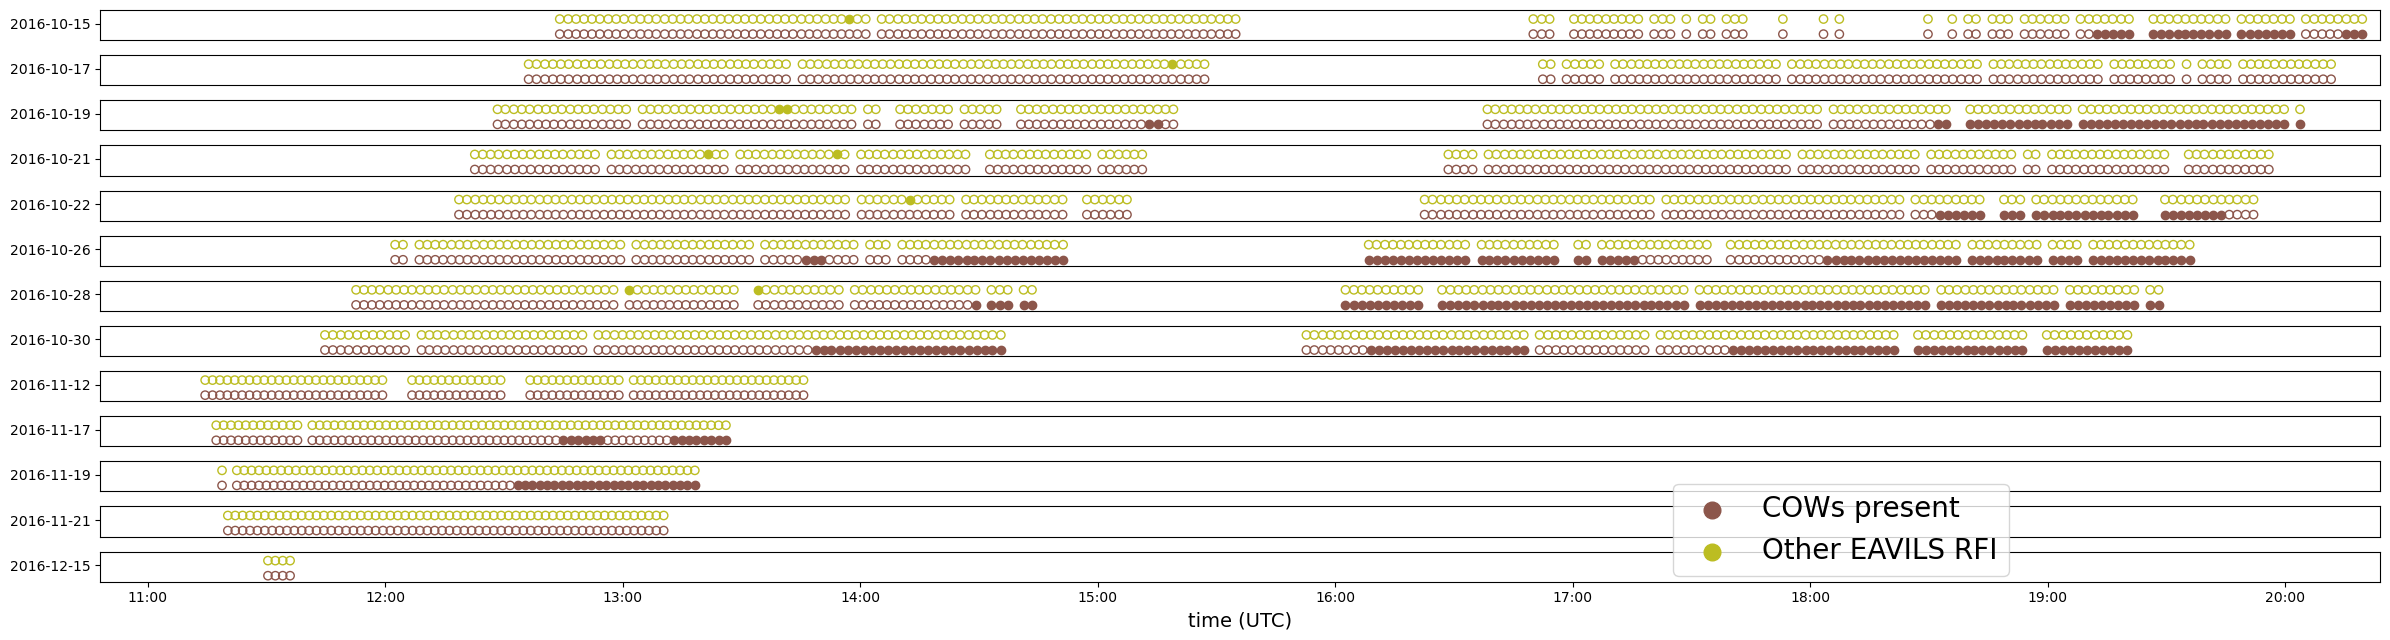

In [26]:
cows_df = pd.read_csv("testing_tutorial/all_processed_cows_data.csv")
cows_df['non cow EAVILS event '] = cows_df['non cow EAVILS event '].fillna(0)

cows_df['Obsid'] = cows_df['Obsid'].astype(str)
times = ['11:00',
 '12:00',
 '13:00',
 '14:00',
 '15:00',
 '16:00',
 '17:00',
 '18:00',
 '19:00',
 '20:00']


mjds = []
for time in cows_df["Obsid"]:
    mjds.append(Time(time, format="gps").mjd)

cows_df["mjd"] = mjds

int_mjds = [np.floor(i) for i in mjds]
days = Time(int_mjds, format='mjd')
obsids = np.array(cows_df["Obsid"])


batchsizes = np.diff(np.where(np.diff(int_mjds, append=0, prepend=len(int_mjds)))[0])
nbatches = len(batchsizes)
fig, ax = plt.subplots(nbatches, 1, layout='tight', figsize=(24, nbatches*.5))


if nbatches ==1:
    ax = [ax]
for i, batchsize in enumerate(batchsizes):
    
    x = np.arange(np.max(batchsizes))  # the label locations

    for j in range(batchsize):
        center_x, center_y = j, 0.9
        
        cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:brown'}
        non_cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:olive'}
        
        index = np.sum(batchsizes[:i]) + j

       
            
        if cows_df.loc[:, "COWS"][index] == 1:
            cows_kwargs['facecolors'] = 'tab:brown'
            
        if cows_df.loc[:, "non cow EAVILS event "][index] == 1:
            non_cows_kwargs['facecolors'] = 'tab:olive'
        

           

        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y , **cows_kwargs) # cows
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y+.5 , **non_cows_kwargs) # other EAVILS events

    ax[i].set_ylim(0.7, 1.7)
    ax[i].set_xticks([])

    ax[i].set_xlim(0.45, 0.85)
    ax[i].set_yticks([1.25],[np.unique(days.to_value('iso', subfmt='date'))[i]])
    

ax[-1].set_xticks([i/24 for i in range(11,21)], times)
plt.xlabel('time (UTC)', fontsize=14)

cows_dot = ax[-1].scatter([], [], color='tab:brown', marker='o', label='COWs present')

non_cows_dot = ax[-1].scatter([], [], color='tab:olive', marker='o', label='Other EAVILS RFI')



fig.legend(handles=[cows_dot,non_cows_dot], loc=(0.7,0.1), fontsize='20', markerscale=2)
plt.show()



We can see here that there is a lot of contaminated data. Let's take data from a night without manually flagged COWs, 10-17-2016, and use that as an estimate for what the standard deviation of the pol-subtracted metric should be for each channel and sky field. Note that we'll also need to exclude any obs IDs that were tagged as containing non-COW-like RFI that EAVILS sees but SSINS doesn't. While the more data the better, a few pointings worth of data should be enough to establish our baseline estimate. These pointings do not have to be from the same night. Here we use three for each sky field. We use the central three pointings, (-1, 0, 1). This avoids the non-cow EAVIL event seen towards the end of 10-17 EOR0 (first section of data on that night).

We will also pre-filter any SSINS-flagged data in our pandas query.

In [27]:
#Picking lists and pointings for each sky field
#                   <sky field>:(<list title>, (<pointigns>)
good_source_dict = {'EOR0':('10-17-2016-EOR0',(-1,0,1)),'EOR1':('10-17-2016-EOR1',(-1,0,1))}


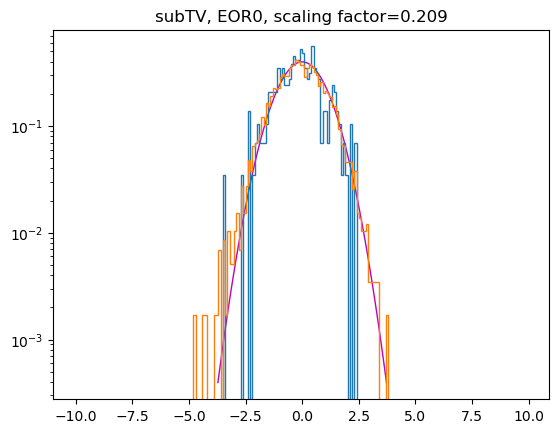

subTV 0.20896901117274233


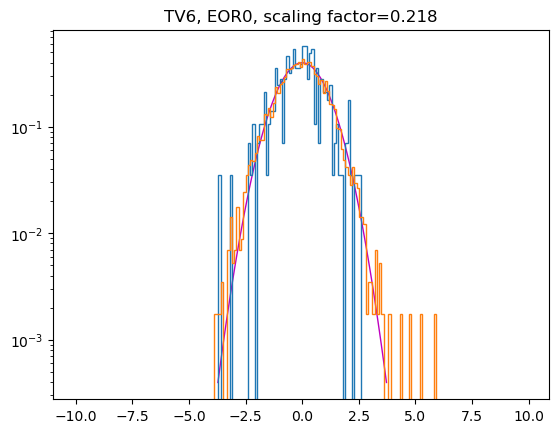

TV6 0.21833098955703328


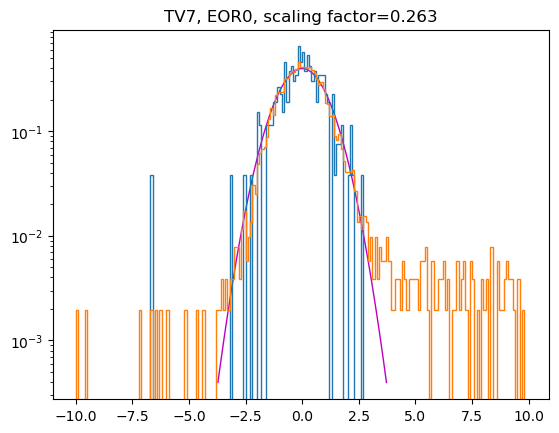

TV7 0.2626662628948124


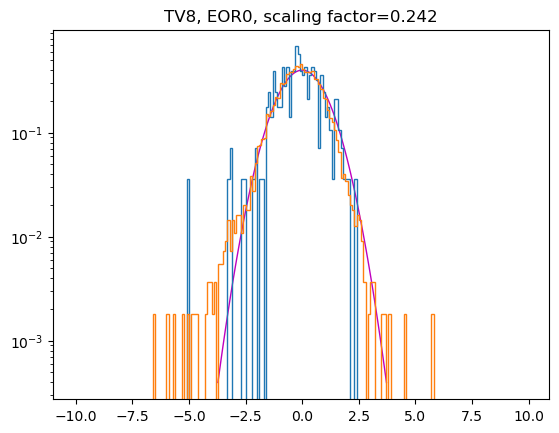

TV8 0.24231910699750378


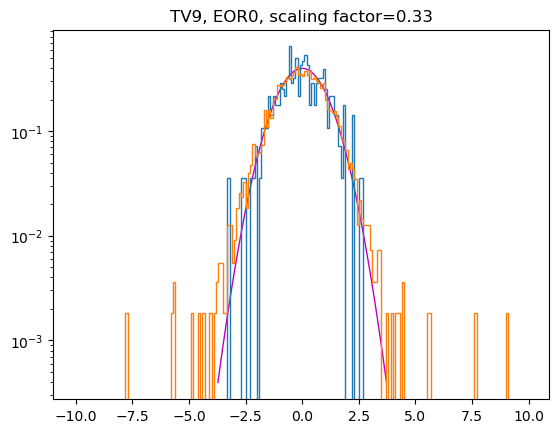

TV9 0.3302941340806336


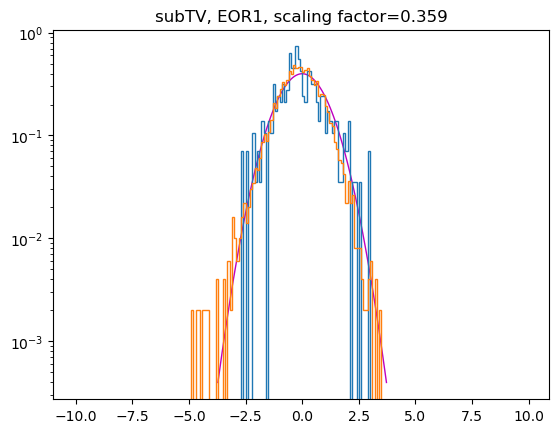

subTV 0.3585768380308905


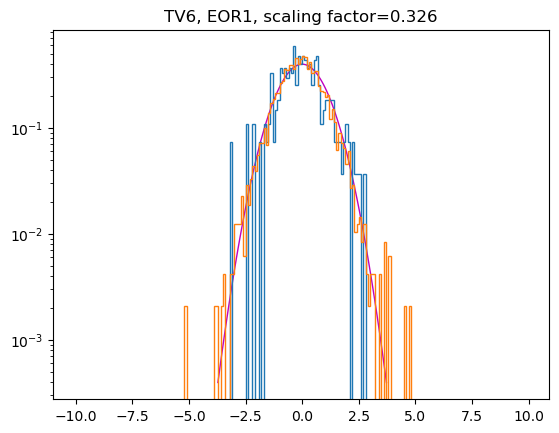

TV6 0.3258501186578795


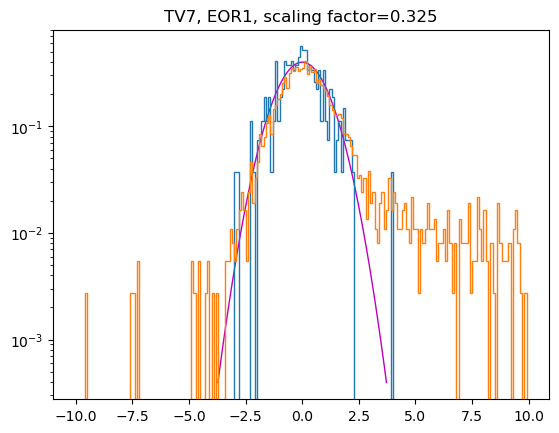

TV7 0.32459299250987744


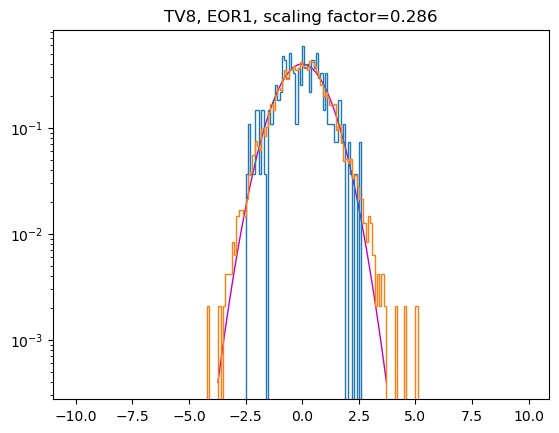

TV8 0.28558882146471676


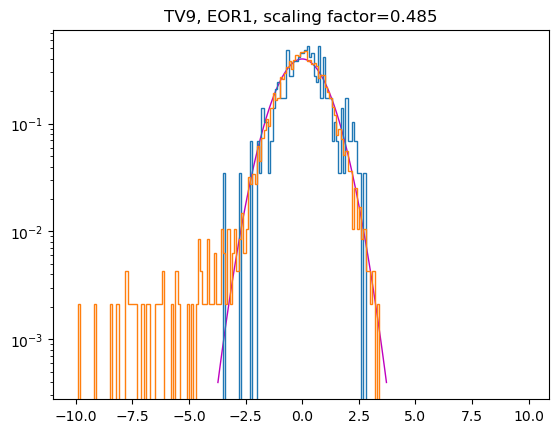

TV9 0.4846056718091971


In [28]:
initial_estimated_pol_sub_stdv= {sky_field:{} for sky_field in sky_field_list}



for sky_field in sky_field_list:
    for freq_range in sorted_freq_ranges:
        
        good_source_list,good_pointings = good_source_dict[sky_field]
        good_pointings = [str(i) for i in good_pointings]
        q_str_add = '['+','.join(good_pointings)+']'
        query_string_clean = f'source_list==\'{good_source_list}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing=={q_str_add}'
        
        pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
        scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
        
        initial_estimated_pol_sub_stdv[sky_field][freq_range] = scaling

        
        pol_sub_series = datafr.query(f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\' & SSINS_flagged=={False}')['pol_sub']

       
    
        plt.yscale('log')
        x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                    scipy.stats.norm.ppf(0.9999,scale=1), 100)
        plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                'm-', lw=1, alpha=1, label='standard normal pdf')
        plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step')
        
        plt.hist((pol_sub_series)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step')


        plt.title(f'{freq_range}, {sky_field}, scaling factor={np.round(scaling,3)}')
        plt.show()
        
        print(freq_range,scaling)
    

Here we have plotted our hand-chosen "clean" data in blue and all data for that frequency range and sky field in orange, with both histograms rescaled using the estimated standard deviation from the clean data, and a standard normal distribution is shown in purple.  We get the following initial estimates for the standard deviation for each field/channel combo:

In [29]:
initial_estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.20896901117274233,
  'TV6': 0.21833098955703328,
  'TV7': 0.2626662628948124,
  'TV8': 0.24231910699750378,
  'TV9': 0.3302941340806336},
 'EOR1': {'subTV': 0.3585768380308905,
  'TV6': 0.3258501186578795,
  'TV7': 0.32459299250987744,
  'TV8': 0.28558882146471676,
  'TV9': 0.4846056718091971}}

Note that the TV9 channel has a markedly higher standard deviation. This is expected, because fewer frequencies are present in that channel within the frequency range the MWA is observing at for this dataset. Thus, fewer values go into the calculation of the variance for each measurement, and so the distribution of variances is wider, and thus the difference between variances between polarizations tends to be higher!

With our initial estimate of the standard deviation for the pol-subtracted metric in mind, we'd like to incorporate more data into our estimate. We thus use our initial estimate as a basis for identifying any pointing that has at least one measurement cross our predetermined threshold in a given frequency range. This is a conservative way to make sure our data is likely to be contamination free. We then get a new estimate of our standard deviation for each pol-subtracted distribution, check against the threshold again, and repeat until our estimates don't change.

iterations: 0
EOR0 subTV estimate shifted by 0.011526963070824764
EOR0 TV6 estimate shifted by 0.005618822263034395
EOR0 TV7 estimate shifted by -0.019968116818850995
EOR0 TV8 estimate shifted by -0.009198194258964482
EOR0 TV9 estimate shifted by 0.029589008734732303
EOR1 subTV estimate shifted by -0.030066787919005633
EOR1 TV6 estimate shifted by -0.009203606332449155
EOR1 TV7 estimate shifted by 0.006169512586775283
EOR1 TV8 estimate shifted by 0.011734197389591583
EOR1 TV9 estimate shifted by -0.03021467206500228
{'EOR0': {'subTV': 0.2204959742435671, 'TV6': 0.22394981182006768, 'TV7': 0.24269814607596138, 'TV8': 0.2331209127385393, 'TV9': 0.3598831428153659}, 'EOR1': {'subTV': 0.3285100501118849, 'TV6': 0.31664651232543034, 'TV7': 0.3307625050966527, 'TV8': 0.29732301885430834, 'TV9': 0.45439099974419483}}
iterations: 1
EOR0 subTV estimate shifted by 0.0
EOR0 TV6 estimate shifted by 0.0
EOR0 TV7 estimate shifted by 0.0
EOR0 TV8 estimate shifted by 0.0
EOR0 TV9 estimate shifted by 0

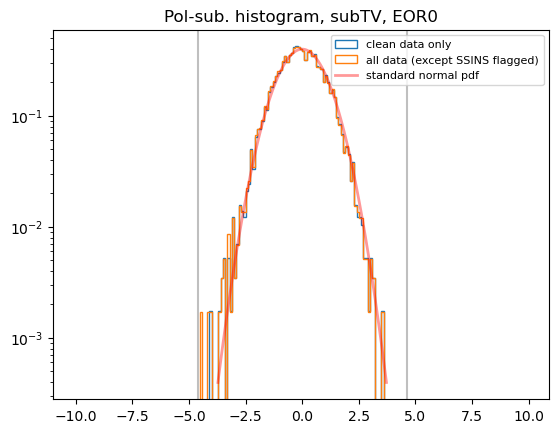

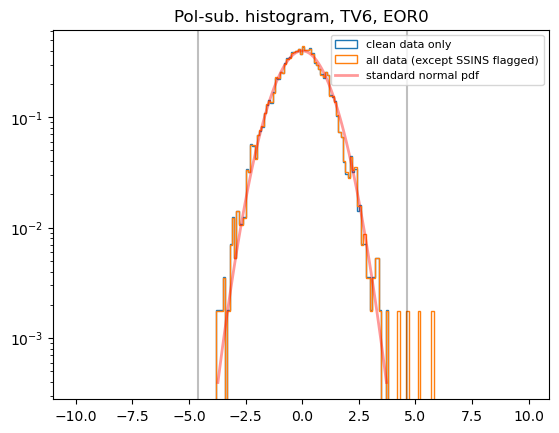

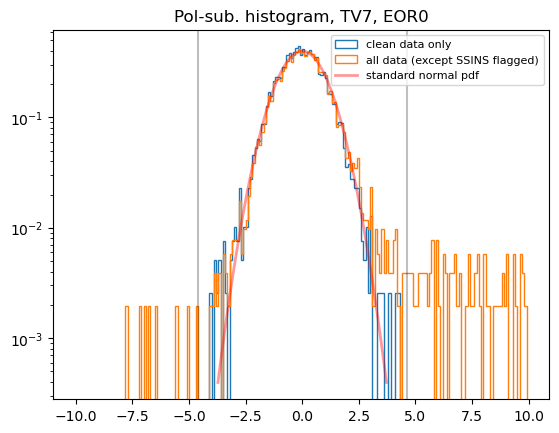

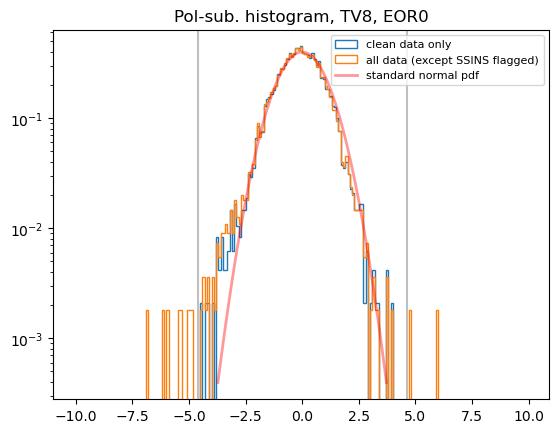

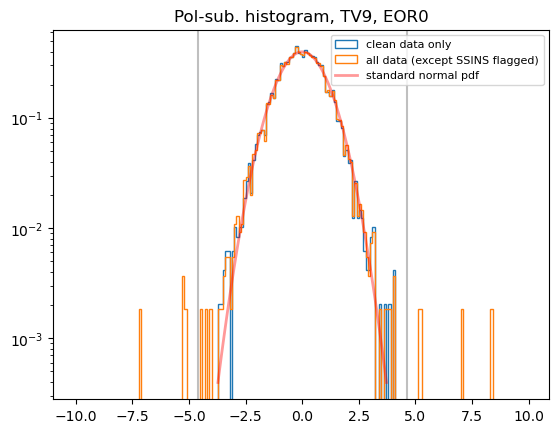

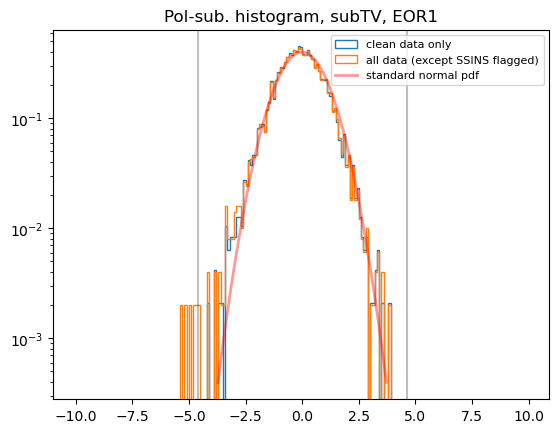

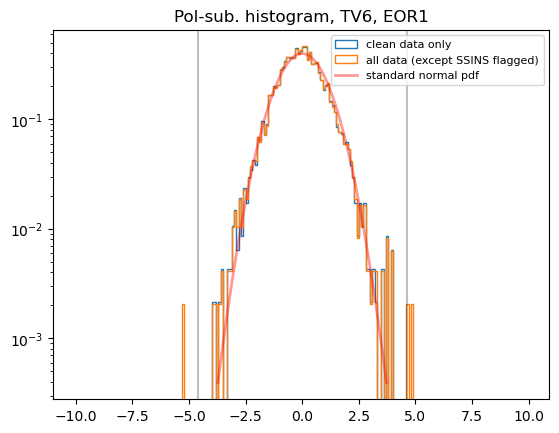

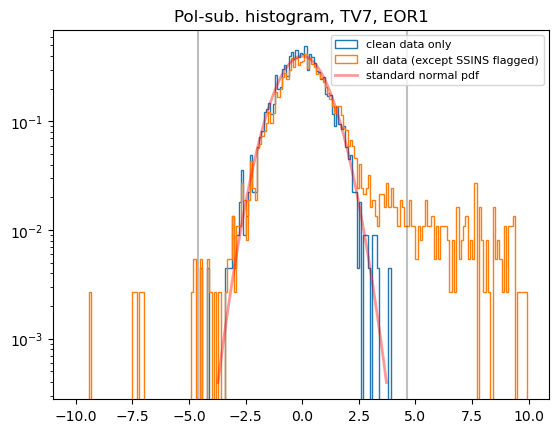

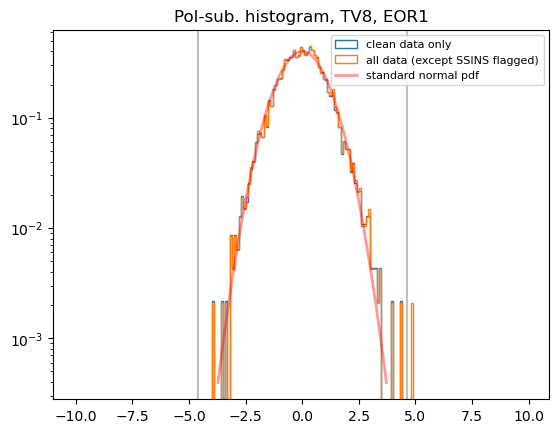

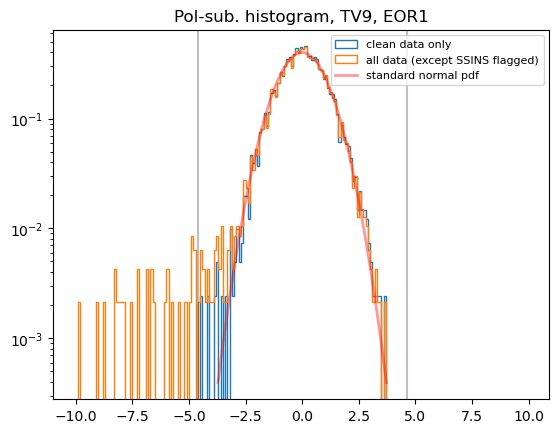

In [30]:
iteration_count=0

datafr['pointing_flagged'] = False #This should already be true, but ensures it's the case

estimated_pol_sub_stdv = deepcopy(initial_estimated_pol_sub_stdv)
while True:
    print('iterations:',iteration_count)
    prev_estimated_pol_sub_stdv = deepcopy(estimated_pol_sub_stdv)
    
    for source_list in np.unique(datafr.source_list):
        
        sky_field = sky_field_list_association[source_list]

        for pointing in np.unique(datafr.pointing):
            for freq_range in sorted_freq_ranges:
                query_string = f'sky_field==\'{sky_field}\' & source_list==\'{source_list}\' & pointing=={pointing} & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                sub_series = datafr.query(query_string)['pol_sub']
                estimated_stdv = estimated_pol_sub_stdv[sky_field][freq_range]
                outliers = np.abs(sub_series)>(estimated_stdv*threshold)
    
                if np.sum(outliers)>0:
                    flag_pointing=True
                else:
                    flag_pointing=False
                if flag_pointing:
                    flagged_indices = datafr.query(query_string).index
                    datafr.loc[flagged_indices,'pointing_flagged'] = True
    
    
    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
            pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
    
            scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
            
            estimated_pol_sub_stdv[sky_field][freq_range] = scaling

    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            print(sky_field,freq_range,'estimate shifted by', estimated_pol_sub_stdv[sky_field][freq_range] - prev_estimated_pol_sub_stdv[sky_field][freq_range])
    print(estimated_pol_sub_stdv) 
    if estimated_pol_sub_stdv==prev_estimated_pol_sub_stdv:    
        for sky_field in sky_field_list:
            for freq_range in sorted_freq_ranges:
                query_string_all = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                pol_sub_series_all = datafr.query(query_string_all)['pol_sub']
                
                query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
                pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
                plt.yscale('log')
                
                scaling = estimated_pol_sub_stdv[sky_field][freq_range]
                
                plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='clean data only')
                plt.hist((pol_sub_series_all)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='all data (except SSINS flagged)')
                plt.vlines([-threshold,threshold],ymin=0,ymax=1,color='black',alpha=.25)
                
                x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                            scipy.stats.norm.ppf(0.9999,scale=1), 100)
                plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                        'r-', lw=2, alpha=0.4, label='standard normal pdf')
                plt.title(f'Pol-sub. histogram, {freq_range}, {sky_field}')
                plt.legend( prop={'size': 8})
                plt.show()
        break
    iteration_count+=1
           

We get the following estimate for standard deviations. We save it out to a yaml file.

In [31]:
estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.2204959742435671,
  'TV6': 0.22394981182006768,
  'TV7': 0.24269814607596138,
  'TV8': 0.2331209127385393,
  'TV9': 0.3598831428153659},
 'EOR1': {'subTV': 0.3258188634424168,
  'TV6': 0.31664651232543034,
  'TV7': 0.3307625050966527,
  'TV8': 0.29732301885430834,
  'TV9': 0.4530546183424038}}

In [32]:
#Yaml is unhappy with numpy floats, so we fix this here
for sky_field,sub_dict in estimated_pol_sub_stdv.items():
        for freq_range,stdv in sub_dict.items():
            estimated_pol_sub_stdv[sky_field][freq_range] = float(stdv)
with open('testing_tutorial/2016_fall_pol_sub_stdv.yml', 'w') as file:
    for sky_field,sub_dict in estimated_pol_sub_stdv.items():
        for freq_range,stdv in sub_dict.items():
            estimated_pol_sub_stdv[sky_field][freq_range] = float(stdv)
            
        
    yaml.safe_dump(estimated_pol_sub_stdv, file, default_flow_style=False, sort_keys=False) 

# 4) Flagging data

We load in this estimated standard deviation for the pol-subtracted metric generated above here.

In [33]:
with open('testing_tutorial/2016_fall_pol_sub_stdv.yml', 'r') as file:
    estimated_pol_sub_stdv = yaml.safe_load(file) # Use safe_load for security

We add this estimated standard deviation to our dataframe and generate flags in this next step.

In [34]:
datafr= proc.add_pol_sub_stdv(datafr,estimated_pol_sub_stdv,threshold)

In [35]:
datafr

,obs_tag,sky_field,t_block_ind,pointing,pol_sub,SSINS_flagged,pointing_flagged,source_list,lst,variance_XX,variance_YY,variance_XY,variance_YX,freq_range,pol_sub_stdv,pol_sub_flagged
0,1160570624,EOR0,0,-3,0.056160,False,False,10-15-2016-EOR0,5.795401,0.930381,0.874221,1.165624,0.805463,subTV,0.220496,False
1,1160570624,EOR0,1,-3,-0.116921,False,False,10-15-2016-EOR0,5.796568,0.833849,0.950770,0.945195,0.821406,subTV,0.220496,False
2,1160570624,EOR0,2,-3,-0.243189,False,False,10-15-2016-EOR0,5.797735,0.796453,1.039642,0.869831,0.716382,subTV,0.220496,False
3,1160570624,EOR0,3,-3,0.256548,False,False,10-15-2016-EOR0,5.798902,0.952697,0.696149,0.715717,0.611442,subTV,0.220496,False
4,1160570624,EOR0,4,-3,-0.009104,False,False,10-15-2016-EOR0,5.800068,0.998381,1.007485,0.792033,1.004230,subTV,0.220496,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58970,1165836936,EOR0,2,2,0.031423,False,False,12-15-2016-EOR0,0.265812,0.652026,0.620603,0.454005,0.835356,TV9,0.359883,False
58971,1165836936,EOR0,3,2,0.599237,True,False,12-15-2016-EOR0,0.266979,1.880602,1.281364,1.193661,1.063842,TV9,0.359883,False
58972,1165836936,EOR0,4,2,-0.559859,True,False,12-15-2016-EOR0,0.268145,1.839106,2.398965,1.362883,1.465797,TV9,0.359883,False
58973,1165836936,EOR0,5,2,-0.630309,True,False,12-15-2016-EOR0,0.269312,1.467617,2.097926,1.850622,1.513904,TV9,0.359883,False


In [36]:

per_pointing_stats=proc.find_per_pointing_stats(datafr=datafr,shape_dict=shape_dict,list_titles=list_titles,threshold=threshold)


Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encou

In [37]:

for list_title in per_pointing_stats.keys():
    print(list_title,'===============================')
    
    for pointing in per_pointing_stats[list_title]['subTV'].keys():
        print('               ',pointing,'____________')
        for freq_range in sorted_freq_ranges:
            local_flagged_count = per_pointing_stats[list_title][freq_range][pointing]['flagged_count']
            if local_flagged_count>0:
                print('                   ',freq_range,':',local_flagged_count)

10-15-2016-EOR0 ===============================
                -3 ____________
                -2 ____________
                -1 ____________
                    TV7 : 6
                0 ____________
                1 ____________
                2 ____________
                    TV7 : 6
                    TV9 : 1
                3 ____________
10-15-2016-EOR1 ===============================
                -3 ____________
                    subTV : 2
                -2 ____________
                -1 ____________
                0 ____________
                1 ____________
                    TV7 : 15
                2 ____________
                    TV7 : 18
                3 ____________
                    TV7 : 27
                    TV9 : 8
10-17-2016-EOR0 ===============================
                -3 ____________
                -2 ____________
                -1 ____________
                    TV7 : 1
                0 ____________
                1 ____________
 

In [38]:
import eavils_waterfalls as wtrf

In [39]:
obs_tag = '1160938096'
eavils = wtrf.EAVILS(f'testing_tutorial/h5_files/{obs_tag}_80khz_cross_EAVILS_data.h5')

In [41]:

expanded_flag_array = proc.flag_expander(
    datafr = datafr,
    obs_tag = obs_tag,
    time_dim = time_dim, 
    Ntimes_total = eavils.Ntimes, 
    shape_dict = shape_dict, 
    freq_array = eavils.freq_array,
    Npols=eavils.Npols)    

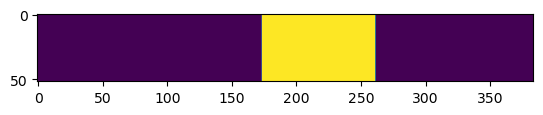

In [42]:
plt.imshow(expanded_flag_array[:,:,0])